# GPT2 from scratch

This notebook is a step by step implementation of a GPT-2 model from scratch using PyTorch. It also works for GPT-3 since GPT-3 is mostly a scaled-up version of GPT-2.

In [1]:
# TODO: visualize attention post training
# TODO: visualize gradient issues
# TODO: without bias?
# TODO: make sampling faster
# TODO: how to measure model quality?
# TODO: karpathy tokenizer video
# TODO: add validation set / step
# TODO: load gpt 2 checkpoint 

BASE_CONFIG = {
    "n_positions": 64, # TODO: call block_size
    "batch_size": 64, #2048 *2, #128,,  # Reduced from 512 to fit in 16GB
    "n_embd": 64,
    "n_head": 2,
    "n_layer": 2,
    "learning_rate": 3e-3,
    #"dropout": 0.1,
    "gradient_accumulation_steps": 8,  # 64 * 8 = 512 effective batch size
    "tune_batch_size": False,
    "layer_norm_enabled": True,
    "tokenizer": "char",
    "n_epochs": 100
}

# Update
GPT2_CONFIG = {
     "n_embd": 768,
      "n_layer": 12,        # Currently 6, needs to be 12
      "n_head": 12,
      "n_positions": 1024,  # Currently 256, needs to be 1024
      "tokenizer": "gpt2"
}

# Update
GPT3_CONFIG = {
    **BASE_CONFIG,
    "n_embd": 4096,
    "n_layer": 96,
    "n_head": 96,
    "n_positions": 1024,
    "tokenizer": "gpt2"
}

CONFIG = {
    **BASE_CONFIG,
    #**GPT2_CONFIG
    #**GPT3_CONFIG
}

def estimate_training_memory_gb(
    config,
    vocab_size=50257,
    dtype="float32",
    optimizer="adamw",
    gradient_checkpointing=False,
    include_buffers=True,
):
    """
    Comprehensive memory estimator for training a GPT-2 style transformer.
    
    This estimates PEAK memory usage during training, which typically occurs
    during the backward pass through the cross-entropy loss.
    
    Args:
        config: Dictionary with model configuration:
            - n_positions: sequence length / block size
            - batch_size: micro-batch size (actual batch per forward pass)
            - n_embd: embedding dimension
            - n_head: number of attention heads
            - n_layer: number of transformer blocks
            - gradient_accumulation_steps: (optional, for display only)
        vocab_size: vocabulary size (default: 50257 for GPT-2)
        dtype: "float32", "float16", "bfloat16", or "mixed" (mixed precision)
        optimizer: "adamw", "adam", "sgd", "sgd_momentum", or "adafactor"
        gradient_checkpointing: if True, trades compute for memory
        include_buffers: include causal masks and other buffers
    
    Returns:
        Dictionary with detailed memory breakdown in GB
    
    Memory Components:
    ==================
    1. Model Parameters: weights of all layers
    2. Gradients: same size as parameters (stored for optimizer step)
    3. Optimizer States: depends on optimizer (AdamW = 2x params)
    4. Activations: stored during forward pass for backprop
       - This is where most memory goes for large batch/sequence!
    5. Peak Backward Memory: temporary tensors during backward pass
    6. Framework Overhead: autograd graph, memory fragmentation, metadata
    7. Buffers: causal masks, position indices (small but present)
    
    Key Insight:
    ============
    Gradient accumulation does NOT multiply activation memory!
    - Forward pass 1 → store activations → backward pass 1 → free activations
    - Forward pass 2 → store activations → backward pass 2 → free activations
    - ... (gradients accumulate, but activations are freed each step)
    - Optimizer step (uses accumulated gradients)
    
    Peak memory occurs during a SINGLE forward-backward pass, not across
    accumulation steps. Gradient accumulation only affects gradients (already counted).
    """
    # Extract config
    n_positions = config["n_positions"]  # T (sequence length)
    batch_size = config["batch_size"]     # B (micro-batch size)
    n_embd = config["n_embd"]             # C (embedding dimension)
    n_head = config["n_head"]             # H (number of heads)
    n_layer = config["n_layer"]           # L (number of layers)
    head_size = n_embd // n_head          # D (dimension per head)
    
    # Bytes per element based on dtype
    DTYPE_BYTES = {
        "float32": 4,
        "float16": 2,
        "bfloat16": 2,
        "mixed": 2,  # Activations in fp16, master weights in fp32
    }
    bytes_per_param = DTYPE_BYTES.get(dtype, 4)
    bytes_per_activation = 2 if dtype == "mixed" else bytes_per_param
    
    # For mixed precision, optimizer keeps fp32 master weights
    bytes_per_master_weight = 4 if dtype == "mixed" else bytes_per_param
    
    # =========================================================================
    # 1. MODEL PARAMETERS (weights + biases)
    # =========================================================================
    
    # Token embeddings: (vocab_size, n_embd)
    token_emb_params = vocab_size * n_embd
    
    # Position embeddings: (n_positions, n_embd)
    pos_emb_params = n_positions * n_embd
    
    # Per transformer block:
    # - QKV projection: Linear(n_embd, 3 * n_embd) → weight + bias
    attn_qkv_params = n_embd * 3 * n_embd + 3 * n_embd  # weight + bias
    # - Output projection: Linear(n_embd, n_embd) → weight + bias
    attn_out_params = n_embd * n_embd + n_embd
    # - FFN up: Linear(n_embd, 4 * n_embd)
    ffn_up_params = n_embd * 4 * n_embd + 4 * n_embd
    # - FFN down: Linear(4 * n_embd, n_embd)
    ffn_down_params = 4 * n_embd * n_embd + n_embd
    # - Layer norms: 2 per block, each has weight + bias of size n_embd
    ln_params_per_block = 2 * (n_embd + n_embd)
    
    params_per_block = attn_qkv_params + attn_out_params + ffn_up_params + ffn_down_params + ln_params_per_block
    
    # Final layer norm
    final_ln_params = n_embd + n_embd
    
    # LM head: Linear(n_embd, vocab_size) - usually tied to token embeddings
    # When tied, no extra params. When not tied, adds vocab_size * n_embd
    lm_head_params = 0  # Assuming weight tying (as in your model)
    
    total_params = token_emb_params + pos_emb_params + (n_layer * params_per_block) + final_ln_params + lm_head_params
    
    # =========================================================================
    # 2. GRADIENTS
    # =========================================================================
    # Same count as parameters, stored in same precision as forward pass
    gradient_elements = total_params
    
    # =========================================================================
    # 3. OPTIMIZER STATES
    # =========================================================================
    # AdamW/Adam: momentum (m) + variance (v) = 2x params, stored in fp32
    # SGD: no states (0x) or momentum only (1x)
    # Adafactor: ~0.5x (row + col factors instead of full states)
    OPTIMIZER_MULTIPLIER = {
        "adamw": 2,
        "adam": 2,
        "sgd": 0,
        "sgd_momentum": 1,
        "adafactor": 0.5,
    }
    optimizer_multiplier = OPTIMIZER_MULTIPLIER.get(optimizer, 2)
    optimizer_state_elements = total_params * optimizer_multiplier
    
    # =========================================================================
    # 4. ACTIVATIONS (Forward Pass - stored for backprop)
    # =========================================================================
    # These are the tensors stored during forward pass that are needed for
    # computing gradients during backward pass.
    
    if gradient_checkpointing:
        # With gradient checkpointing, only store activations at layer boundaries
        # Recompute within-layer activations during backward (trades compute for memory)
        # Roughly stores: input to each layer + final output
        activation_elements = (
            batch_size * n_positions * n_embd * (n_layer + 2)  # Layer inputs + embeddings
        )
    else:
        # Full activation storage (no checkpointing)
        
        # Input embeddings: (B, T, C)
        input_emb_act = batch_size * n_positions * n_embd
        
        # Per transformer block activations:
        # 
        # Attention:
        # - Input to attention (after LN1): (B, T, C)
        attn_input = batch_size * n_positions * n_embd
        # - Q, K, V after projection: 3 × (B, H, T, D)
        qkv_act = 3 * batch_size * n_head * n_positions * head_size
        # - Attention scores (QK^T / sqrt(d)): (B, H, T, T) - THIS IS HUGE FOR LONG SEQUENCES
        attn_scores = batch_size * n_head * n_positions * n_positions
        # - Attention weights (after softmax): (B, H, T, T) - saved for backward
        attn_weights = batch_size * n_head * n_positions * n_positions
        # - Attention output (before W_o): (B, H, T, D)
        attn_output_pre = batch_size * n_head * n_positions * head_size
        # - Attention output (after W_o): (B, T, C)
        attn_output_post = batch_size * n_positions * n_embd
        
        attn_act_per_block = attn_input + qkv_act + attn_scores + attn_weights + attn_output_pre + attn_output_post
        
        # FFN:
        # - Input to FFN (after LN2): (B, T, C)
        ffn_input = batch_size * n_positions * n_embd
        # - After first linear (expansion): (B, T, 4C)
        ffn_expanded = batch_size * n_positions * 4 * n_embd
        # - After GELU: (B, T, 4C) - GELU saves input for backward
        ffn_gelu_input = batch_size * n_positions * 4 * n_embd
        # - After second linear: (B, T, C)
        ffn_output = batch_size * n_positions * n_embd
        
        ffn_act_per_block = ffn_input + ffn_expanded + ffn_gelu_input + ffn_output
        
        # Residual stream saved at each block (for residual connection backward)
        residual_per_block = 2 * batch_size * n_positions * n_embd
        
        act_per_block = attn_act_per_block + ffn_act_per_block + residual_per_block
        
        # Final layer norm input: (B, T, C)
        final_ln_input = batch_size * n_positions * n_embd
        
        # LM head output / logits: (B, T, V) - THIS IS MASSIVE!
        logits_act = batch_size * n_positions * vocab_size
        
        activation_elements = input_emb_act + (n_layer * act_per_block) + final_ln_input + logits_act
    
    # =========================================================================
    # 5. PEAK BACKWARD MEMORY
    # =========================================================================
    # During backward pass, additional temporary tensors are created.
    # The peak typically occurs at the cross-entropy loss backward.
    
    # Cross-entropy backward creates:
    # - Softmax output: (B, T, V) - computed during forward, but may be recomputed
    # - Gradient of logits: (B, T, V) - flows back through lm_head
    # These exist simultaneously at the peak!
    cross_entropy_peak = 2 * batch_size * n_positions * vocab_size
    
    # During attention backward (for each layer):
    # - Gradients for Q, K, V: 3 × (B, H, T, D)
    # - Gradient for attention weights: (B, H, T, T)
    # These are computed sequentially per layer, so only one layer's worth at a time
    attn_backward_peak = (
        3 * batch_size * n_head * n_positions * head_size +  # dQ, dK, dV
        batch_size * n_head * n_positions * n_positions       # dAttn_weights
    )
    
    # The true peak is the larger of cross-entropy backward or attention backward
    # Cross-entropy is almost always larger due to vocab_size
    backward_peak = max(cross_entropy_peak, attn_backward_peak)
    
    # =========================================================================
    # 6. BUFFERS (causal masks, position indices, etc.)
    # =========================================================================
    if include_buffers:
        # Causal mask: (T, T) boolean or float, stored once per layer or shared
        causal_mask = n_positions * n_positions * n_layer  # Could be shared, being conservative
        # Position indices: (T,) int64
        position_indices = n_positions * 2  # int64 = 8 bytes, but negligible
        buffer_elements = causal_mask + position_indices
    else:
        buffer_elements = 0
    
    # =========================================================================
    # 7. FRAMEWORK OVERHEAD
    # =========================================================================
    # PyTorch autograd graph, tensor metadata, memory allocator fragmentation
    # This is hard to estimate precisely, but typically 5-15% overhead
    # We'll compute this as a factor on the total
    
    # =========================================================================
    # CONVERT TO BYTES AND GB
    # =========================================================================
    def to_gb(elements, bytes_each):
        return (elements * bytes_each) / (1024**3)
    
    # Model weights
    model_memory_gb = to_gb(total_params, bytes_per_param)
    if dtype == "mixed":
        # Mixed precision: fp16 weights + fp32 master copy
        model_memory_gb = to_gb(total_params, 2) + to_gb(total_params, 4)
    
    # Gradients (same precision as forward)
    gradient_memory_gb = to_gb(gradient_elements, bytes_per_param)
    
    # Optimizer states (always fp32 for numerical stability)
    optimizer_memory_gb = to_gb(optimizer_state_elements, 4)  # Always fp32
    
    # Activations
    activation_memory_gb = to_gb(activation_elements, bytes_per_activation)
    
    # Peak backward memory
    backward_peak_gb = to_gb(backward_peak, bytes_per_activation)
    
    # Buffers (typically fp32 or bool)
    buffer_memory_gb = to_gb(buffer_elements, 4)
    
    # =========================================================================
    # TOTAL MEMORY CALCULATION
    # =========================================================================
    # Static memory (always present during training):
    static_memory_gb = model_memory_gb + gradient_memory_gb + optimizer_memory_gb + buffer_memory_gb
    
    # Dynamic memory (activations + backward peak):
    # Note: backward_peak overlaps with some activations being freed, so we don't
    # simply add them. The peak is roughly: activations + backward_peak * 0.5
    # (because some activations are freed before backward peak is needed)
    # Being conservative, we use 0.7 factor
    dynamic_memory_gb = activation_memory_gb + backward_peak_gb * 0.7
    
    # Framework overhead: ~10% of total
    subtotal_gb = static_memory_gb + dynamic_memory_gb
    framework_overhead_gb = subtotal_gb * 0.10
    
    # Total peak memory
    total_memory_gb = subtotal_gb + framework_overhead_gb
    
    # =========================================================================
    # DETAILED BREAKDOWN FOR ANALYSIS
    # =========================================================================
    logits_memory_gb = to_gb(batch_size * n_positions * vocab_size, bytes_per_activation)
    attn_matrix_per_block_gb = to_gb(2 * batch_size * n_head * n_positions * n_positions, bytes_per_activation)
    
    return {
        # Summary
        "total_memory_gb": total_memory_gb,
        "total_params": total_params,
        
        # Static memory (always allocated)
        "model_memory_gb": model_memory_gb,
        "gradient_memory_gb": gradient_memory_gb,
        "optimizer_memory_gb": optimizer_memory_gb,
        "buffer_memory_gb": buffer_memory_gb,
        "static_memory_gb": static_memory_gb,
        
        # Dynamic memory (during forward/backward)
        "activation_memory_gb": activation_memory_gb,
        "backward_peak_gb": backward_peak_gb,
        "dynamic_memory_gb": dynamic_memory_gb,
        
        # Framework overhead
        "framework_overhead_gb": framework_overhead_gb,
        
        # Detailed breakdown
        "logits_memory_gb": logits_memory_gb,
        "cross_entropy_peak_gb": to_gb(cross_entropy_peak, bytes_per_activation),
        "attn_matrix_per_block_gb": attn_matrix_per_block_gb,
        
        # Config echo
        "config": {
            "batch_size": batch_size,
            "n_positions": n_positions,
            "n_embd": n_embd,
            "n_head": n_head,
            "n_layer": n_layer,
            "vocab_size": vocab_size,
            "dtype": dtype,
            "optimizer": optimizer,
            "gradient_checkpointing": gradient_checkpointing,
        },
        
        # Parameter breakdown
        "param_breakdown": {
            "token_embeddings": token_emb_params,
            "position_embeddings": pos_emb_params,
            "transformer_blocks": n_layer * params_per_block,
            "final_layer_norm": final_ln_params,
            "lm_head": lm_head_params,
        },
    }


def print_memory_estimate(estimate):
    """Pretty print the memory estimate."""
    print("=" * 75)
    print("  TRAINING MEMORY ESTIMATE")
    print("=" * 75)
    
    cfg = estimate["config"]
    print(f"\n📋 Configuration:")
    print(f"   Model: {cfg['n_layer']}L-{cfg['n_head']}H-{cfg['n_embd']}D, vocab={cfg['vocab_size']:,}")
    print(f"   Training: batch={cfg['batch_size']}, seq_len={cfg['n_positions']}, dtype={cfg['dtype']}")
    print(f"   Optimizer: {cfg['optimizer']}, checkpointing={cfg['gradient_checkpointing']}")
    print(f"   Parameters: {estimate['total_params']:,} ({estimate['total_params']/1e6:.2f}M)")
    
    print(f"\n📊 Memory Breakdown:")
    print(f"   ┌─ Static Memory (always allocated) ──────────────────────────────┐")
    print(f"   │  Model weights:      {estimate['model_memory_gb']:>8.3f} GB                          │")
    print(f"   │  Gradients:          {estimate['gradient_memory_gb']:>8.3f} GB                          │")
    print(f"   │  Optimizer states:   {estimate['optimizer_memory_gb']:>8.3f} GB                          │")
    print(f"   │  Buffers:            {estimate['buffer_memory_gb']:>8.3f} GB                          │")
    print(f"   │  ─────────────────────────────────────                          │")
    print(f"   │  Static subtotal:    {estimate['static_memory_gb']:>8.3f} GB                          │")
    print(f"   └─────────────────────────────────────────────────────────────────┘")
    
    print(f"   ┌─ Dynamic Memory (forward/backward pass) ────────────────────────┐")
    print(f"   │  Activations:        {estimate['activation_memory_gb']:>8.3f} GB                          │")
    print(f"   │  Backward peak:      {estimate['backward_peak_gb']:>8.3f} GB                          │")
    print(f"   │  ─────────────────────────────────────                          │")
    print(f"   │  Dynamic subtotal:   {estimate['dynamic_memory_gb']:>8.3f} GB                          │")
    print(f"   └─────────────────────────────────────────────────────────────────┘")
    
    print(f"   ┌─ Overhead ───────────────────────────────────────────────────────┐")
    print(f"   │  Framework (10%):    {estimate['framework_overhead_gb']:>8.3f} GB                          │")
    print(f"   └─────────────────────────────────────────────────────────────────┘")
    
    print(f"\n🎯 TOTAL PEAK MEMORY:     {estimate['total_memory_gb']:>8.3f} GB")
    
    print(f"\n⚠️  Largest Memory Consumers:")
    print(f"   • Logits tensor (B×T×V):       {estimate['logits_memory_gb']:.3f} GB")
    print(f"   • Cross-entropy backward:      {estimate['cross_entropy_peak_gb']:.3f} GB")
    print(f"   • Attention matrices (per L):  {estimate['attn_matrix_per_block_gb']:.3f} GB")
    
    # Recommendations
    total = estimate['total_memory_gb']
    print(f"\n💡 Recommendations for your {cfg['batch_size']}×{cfg['n_positions']} config:")
    if total > 14:
        print(f"   ❌ Too large for 16GB! Reduce batch_size or use gradient accumulation")
        safe_batch = max(1, int(cfg['batch_size'] * 12 / total))
        print(f"   → Try batch_size={safe_batch} with gradient_accumulation_steps={cfg['batch_size']//safe_batch}")
    elif total > 12:
        print(f"   ⚠️  Tight fit for 16GB. May OOM under memory pressure.")
        print(f"   → Consider reducing batch_size slightly or using gradient checkpointing")
    elif total > 8:
        print(f"   ✅ Should fit in 16GB with some headroom")
    else:
        print(f"   ✅ Comfortable fit in 16GB")
        if cfg['batch_size'] < 128:
            print(f"   → You could likely increase batch_size for faster training")
    
    print("=" * 75)


def find_max_batch_size(
    config,
    memory_budget_gb=14.0,
    target_effective_batch=None,
    vocab_size=50257,
    dtype="float32",
    optimizer="adamw",
    gradient_checkpointing=False,
):
    """
    Find the maximum batch size that fits in memory, with gradient accumulation.
    
    Args:
        config: Base config dict (batch_size will be overridden)
        memory_budget_gb: Available GPU memory (default 14GB for 16GB card with OS overhead)
        target_effective_batch: Desired effective batch size (batch_size × grad_accum)
        vocab_size: Vocabulary size
        dtype: Data type for training
        optimizer: Optimizer type
        gradient_checkpointing: Whether using gradient checkpointing
    
    Returns:
        Dictionary with recommended batch_size and gradient_accumulation_steps
    """
    # Binary search for max batch size
    low, high = 1, 2048
    max_batch = 1
    
    test_config = config.copy()
    
    while low <= high:
        mid = (low + high) // 2
        test_config["batch_size"] = mid
        
        estimate = estimate_training_memory_gb(
            test_config,
            vocab_size=vocab_size,
            dtype=dtype,
            optimizer=optimizer,
            gradient_checkpointing=gradient_checkpointing,
        )
        
        if estimate["total_memory_gb"] <= memory_budget_gb:
            max_batch = mid
            low = mid + 1
        else:
            high = mid - 1
    
    # Calculate gradient accumulation steps if target effective batch specified
    if target_effective_batch:
        grad_accum = max(1, target_effective_batch // max_batch)
        effective_batch = max_batch * grad_accum
    else:
        grad_accum = 1
        effective_batch = max_batch
    
    # Get final memory estimate
    test_config["batch_size"] = max_batch
    final_estimate = estimate_training_memory_gb(
        test_config,
        vocab_size=vocab_size,
        dtype=dtype,
        optimizer=optimizer,
        gradient_checkpointing=gradient_checkpointing,
    )
    
    return {
        "batch_size": max_batch,
        "gradient_accumulation_steps": grad_accum,
        "effective_batch_size": effective_batch,
        "estimated_memory_gb": final_estimate["total_memory_gb"],
        "memory_budget_gb": memory_budget_gb,
        "headroom_gb": memory_budget_gb - final_estimate["total_memory_gb"],
    }


# Estimate memory requirements
vocab_size = 50257  # GPT-2 tokenizer vocab size
memory_estimate = estimate_training_memory_gb(
    CONFIG,
    vocab_size=vocab_size,
    dtype="float32",        # or "float16", "bfloat16", "mixed"
    optimizer="adamw",      # or "adam", "sgd", "sgd_momentum", "adafactor"
    gradient_checkpointing=False,
)
print_memory_estimate(memory_estimate)

# Find optimal batch size for your hardware
# recommended = find_max_batch_size(
#     CONFIG,
#     memory_budget_gb=14.0,         # Leave ~2GB for OS on 16GB Mac
#     target_effective_batch=512,    # Desired effective batch size
# )
# print(f"\n🎯 Recommended settings for 16GB:")
# print(f"   batch_size: {recommended['batch_size']}")
# print(f"   gradient_accumulation_steps: {recommended['gradient_accumulation_steps']}")
# print(f"   effective_batch_size: {recommended['effective_batch_size']}")
# print(f"   estimated_memory: {recommended['estimated_memory_gb']:.2f} GB")

def free_memory(verbose=True, aggressive=False):
    """
    Free up memory by deleting large objects and clearing caches.
    Use this when you need to free memory without restarting the kernel.
    
    Args:
        verbose: Show detailed output
        aggressive: If True, also delete large objects found automatically
    
    This function:
    1. Deletes common large variables (model, optimizer, data loaders, etc.)
    2. Clears MPS/CUDA caches multiple times
    3. Forces multiple rounds of garbage collection
    4. Shows memory before/after (if verbose)
    
    Usage:
        free_memory()  # Standard cleanup
        free_memory(aggressive=True)  # More aggressive cleanup
    """
    import gc
    import sys
    
    # Get memory before cleanup
    mem_before = None
    if verbose:
        try:
            import psutil
            process = psutil.Process()
            mem_before = process.memory_info().rss / (1024**3)  # GB
            print(f"\n🧹 Memory cleanup starting...")
            print(f"   Memory before: {mem_before:.2f} GB")
        except ImportError:
            print(f"\n🧹 Memory cleanup starting...")
            print(f"   (Install psutil for memory stats: pip install psutil)")
    
    # Get all namespaces (Jupyter notebooks use user_ns)
    namespaces = [globals()]
    try:
        from IPython import get_ipython
        ipython = get_ipython()
        if ipython is not None:
            namespaces.append(ipython.user_ns)
    except:
        pass
    
    # List of common variable names to delete
    vars_to_delete = [
        'model', 'model_pretrained',
        'optimizer',
        'train_loader', 'val_loader', 'test_loader',
        'train_dataset', 'val_dataset', 'test_dataset',
        'x', 'y', 'logits', 'loss', 'losses', 'grad_norms',
        'stats', 'output_tokens', 'tokens_t',
        'attention', 'Q', 'K', 'V', 'QKt', 'QKt_scaled', 'QKt_masked',
        'mha_out', 'ffn_out', 'out',
        'memory_estimate',
        'token_embedding_table', 'position_embedding_table',  # These can be large
        'padded', 'tokens_emb', 'positions_emb',  # Test tensors
    ]
    
    deleted_count = 0
    deleted_vars = []
    
    # Delete from all namespaces
    for namespace in namespaces:
        for var_name in vars_to_delete:
            if var_name in namespace:
                try:
                    del namespace[var_name]
                    deleted_count += 1
                    deleted_vars.append(var_name)
                except:
                    pass
    
    # Aggressive mode: find and delete large objects
    if aggressive:
        if verbose:
            print(f"   🔍 Aggressive mode: searching for large objects...")
        
        for namespace in namespaces:
            for name, obj in list(namespace.items()):
                if name.startswith('_') or name in ['torch', 'gc', 'sys', 'CONFIG', 'BASE_CONFIG', 
                                                     'TOKENIZER', 'DEVICE', 'DATASET_TEXT', 'DATASET_TOKENS',
                                                     'encode', 'decode', 'pad', 'sample_batch']:
                    continue
                
                try:
                    # Check if it's a large PyTorch tensor or model
                    size = 0
                    if hasattr(obj, 'element_size') and hasattr(obj, 'nelement'):
                        size = obj.element_size() * obj.nelement()
                    elif hasattr(obj, 'parameters'):
                        size = sum(p.numel() * (p.element_size() if hasattr(p, 'element_size') else 4)
                                  for p in obj.parameters())
                    elif isinstance(obj, (list, tuple)) and len(obj) > 1000:
                        size = sys.getsizeof(obj)
                    
                    # Delete if > 10MB
                    if size > 10 * 1024 * 1024:
                        try:
                            del namespace[name]
                            deleted_count += 1
                            deleted_vars.append(name)
                            if verbose:
                                print(f"      Deleted large object: {name} ({size / (1024**2):.1f} MB)")
                        except:
                            pass
                except:
                    pass
    
    # Clear PyTorch caches multiple times (MPS sometimes needs multiple clears)
    if torch.backends.mps.is_available():
        for i in range(3):  # Multiple clears for MPS
            torch.mps.empty_cache()
        if verbose:
            print(f"   ✓ Cleared MPS cache (3x)")
    elif torch.cuda.is_available():
        for i in range(3):
            torch.cuda.empty_cache()
        if verbose:
            print(f"   ✓ Cleared CUDA cache (3x)")
    
    # Multiple rounds of garbage collection
    total_collected = 0
    for i in range(3):
        collected = gc.collect()
        total_collected += collected
    
    if verbose:
        print(f"   ✓ Garbage collected {total_collected} objects (3 rounds)")
        print(f"   ✓ Deleted {deleted_count} variables: {', '.join(deleted_vars[:10])}")
        if len(deleted_vars) > 10:
            print(f"      ... and {len(deleted_vars) - 10} more")
    
    # Get memory after cleanup
    if verbose and mem_before is not None:
        try:
            mem_after = process.memory_info().rss / (1024**3)  # GB
            freed = mem_before - mem_after
            print(f"   Memory after:  {mem_after:.2f} GB")
            print(f"   Memory freed:  {freed:.2f} GB")
            if freed < 0.1:
                print(f"   ⚠️  Warning: Little memory freed. Try aggressive=True or manual cleanup.")
            print(f"   ✅ Memory cleanup complete!")
        except:
            print(f"   ✅ Memory cleanup complete!")
    
    return deleted_count

def show_memory_usage():
    """
    Show memory usage of large variables in the current namespace.
    Helps identify what's consuming memory.
    """
    import sys
    
    print("=" * 70)
    print("MEMORY USAGE BY VARIABLE")
    print("=" * 70)
    
    # Get all variables in global scope
    vars_dict = globals()
    
    # Calculate size of each variable
    var_sizes = []
    for name, obj in vars_dict.items():
        if not name.startswith('_'):
            try:
                size = sys.getsizeof(obj)
                # For PyTorch tensors, get actual memory
                if hasattr(obj, 'element_size') and hasattr(obj, 'nelement'):
                    size = obj.element_size() * obj.nelement()
                elif hasattr(obj, '__dict__'):
                    # For models, estimate size
                    if hasattr(obj, 'parameters'):
                        size = sum(p.numel() * p.element_size() if hasattr(p, 'numel') else 0 
                                  for p in obj.parameters())
                
                if size > 1024 * 1024:  # Only show variables > 1MB
                    var_sizes.append((name, size / (1024**2)))  # MB
            except:
                pass
    
    # Sort by size
    var_sizes.sort(key=lambda x: x[1], reverse=True)
    
    if var_sizes:
        print(f"{'Variable':<30} {'Size (MB)':>15} {'Size (GB)':>15}")
        print("-" * 70)
        for name, size_mb in var_sizes[:20]:  # Top 20
            size_gb = size_mb / 1024
            print(f"{name:<30} {size_mb:>15.2f} {size_gb:>15.3f}")
    else:
        print("No large variables found (>1MB)")
    
    print("=" * 70)
    print("\n💡 To free memory, run: free_memory()")
    print("💡 For aggressive cleanup, manually delete variables:")
    print("   del model, optimizer, train_loader, x, y, logits, loss")
    print("   torch.mps.empty_cache()  # or torch.cuda.empty_cache()")
    print("   import gc; gc.collect()")
    print("=" * 70)

def force_mps_cleanup():
    """
    Force MPS to release all memory. Use this if MPS is holding onto memory
    even after free_memory().
    
    Note: This may cause a brief pause as MPS releases memory back to the system.
    MPS on macOS uses unified memory, so it may not release immediately.
    """
    if torch.backends.mps.is_available():
        print("🔄 Forcing MPS memory cleanup...")
        # Multiple aggressive clears
        for i in range(5):
            torch.mps.empty_cache()
        import gc
        for i in range(3):
            gc.collect()
        print("✅ MPS cleanup complete")
        print("⚠️  Note: MPS uses unified memory. Memory may not be released immediately.")
        print("   If memory is still high, try restarting the kernel.")
    else:
        print("⚠️  MPS not available, nothing to clean")

# Example usage (uncomment when needed):
# free_memory()  # Standard cleanup
# free_memory(aggressive=True)  # More aggressive - finds and deletes large objects automatically  
# force_mps_cleanup()  # If MPS is still holding memory after free_memory()
# show_memory_usage()  # See what's using memory


  TRAINING MEMORY ESTIMATE

📋 Configuration:
   Model: 2L-2H-64D, vocab=50,257
   Training: batch=64, seq_len=64, dtype=float32
   Optimizer: adamw, checkpointing=False
   Parameters: 3,320,640 (3.32M)

📊 Memory Breakdown:
   ┌─ Static Memory (always allocated) ──────────────────────────────┐
   │  Model weights:         0.012 GB                          │
   │  Gradients:             0.012 GB                          │
   │  Optimizer states:      0.025 GB                          │
   │  Buffers:               0.000 GB                          │
   │  ─────────────────────────────────────                          │
   │  Static subtotal:       0.050 GB                          │
   └─────────────────────────────────────────────────────────────────┘
   ┌─ Dynamic Memory (forward/backward pass) ────────────────────────┐
   │  Activations:           0.812 GB                          │
   │  Backward peak:         1.534 GB                          │
   │  ────────────────────────────────

Select training device:

In [2]:
import torch
DEVICE = torch.device("mps")

Load dataset:

In [3]:
with open("data/lotr.txt", "r", encoding="latin-1") as f: DATASET_TEXT = f.read()

In [4]:
chars = sorted(list(set(DATASET_TEXT)))
len(chars), chars

(81,
 ['\n',
  ' ',
  '!',
  '"',
  "'",
  '(',
  ')',
  '*',
  ',',
  '-',
  '.',
  '/',
  '0',
  '1',
  '2',
  '3',
  '4',
  '5',
  '6',
  '7',
  '8',
  '9',
  ':',
  ';',
  '=',
  '?',
  'A',
  'B',
  'C',
  'D',
  'E',
  'F',
  'G',
  'H',
  'I',
  'J',
  'K',
  'L',
  'M',
  'N',
  'O',
  'P',
  'Q',
  'R',
  'S',
  'T',
  'U',
  'V',
  'W',
  'X',
  'Y',
  'Z',
  'a',
  'b',
  'c',
  'd',
  'e',
  'f',
  'g',
  'h',
  'i',
  'j',
  'k',
  'l',
  'm',
  'n',
  'o',
  'p',
  'q',
  'r',
  's',
  't',
  'u',
  'v',
  'w',
  'x',
  'y',
  'z',
  '½',
  '¿',
  'ï'])

Create tokenizer:

In [5]:
ctoi = {c:i for i, c in enumerate(chars)}
itoc = {i:c for i, c in enumerate(chars)}
encode = lambda text: [ctoi[c] for c in text]
decode = lambda tokens: "".join([itoc[i] for i in tokens])
decode(encode("hello world")), encode("hello world"), len(ctoi)

('hello world', [59, 56, 63, 63, 66, 1, 74, 66, 69, 63, 55], 81)

Wrap tokenizer in a class:

In [6]:
class CharacterTokenizer:
    def __init__(self, text):
        self.chars = sorted(list(set(text)))
        self.ctoi = {c:i for i, c in enumerate(self.chars)}
        self.itoc = {i:c for i, c in enumerate(self.chars)}
        
    def encode(self, text):
        return [self.ctoi[c] for c in text]
    
    def decode(self, tokens):
        return "".join([self.itoc[i] for i in tokens])

    def get_vocab_size(self):
        return len(self.ctoi) + 1

    def get_pad_id(self):
        return len(self.ctoi)


Test GPT2 tokenizer (subword tokenizer):

In [7]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")
encode = tokenizer.encode
decode = tokenizer.decode
decode(encode("hello world")), encode("hello world")

('hello world', [31373, 995])

Wrap GPT2 tokenizer in a class with same interface as the character tokenizer:

In [8]:
class GPT2Tokenizer:
    def __init__(self, text):
        self.tokenizer = tiktoken.get_encoding("gpt2")
        
    def encode(self, text):
        return self.tokenizer.encode(text)
    
    def decode(self, tokens):
        return self.tokenizer.decode(tokens)

    def get_vocab_size(self):
        return self.tokenizer.n_vocab + 1

    def get_pad_id(self):
        return self.tokenizer.n_vocab
        

Instantiate the chosen tokenizer:

In [9]:
tokenizer_cls = GPT2Tokenizer if CONFIG["tokenizer"] == "gpt2" else CharacterTokenizer
TOKENIZER = tokenizer_cls(DATASET_TEXT)

Create token embedding table:

In [10]:
import torch
import torch.nn as nn

# Retrieve params
n_embd = CONFIG["n_embd"]
n_positions = CONFIG["n_positions"]
pad_id = TOKENIZER.get_pad_id()
vocab_size = TOKENIZER.get_vocab_size() 

# Encode and pad to max sequence length
tokens = TOKENIZER.encode("hello")
pad = lambda tokens: tokens + [pad_id] * (n_positions - len(tokens))
tokens = pad(tokens)
padded = torch.tensor(tokens)

# Create token embedding table (lookup table of with token ids as keys and embeddings as values)
# embeddings are random initialized and then tuned during training
token_embedding_table = nn.Embedding(vocab_size, n_embd)

# Embed tokens
tokens_emb = token_embedding_table(padded)
tokens_emb.shape, tokens_emb

(torch.Size([64, 64]),
 tensor([[-1.3327e-01,  3.2690e-01,  2.0114e+00,  ...,  7.3281e-04,
           5.9039e-01, -1.1658e+00],
         [ 6.2960e-01,  5.8141e-01,  9.5333e-01,  ..., -9.1334e-01,
          -3.7989e-01,  1.3805e-01],
         [ 1.0413e+00, -1.0551e+00,  2.1470e+00,  ...,  6.3433e-01,
           1.8490e+00,  4.6861e-01],
         ...,
         [ 9.7390e-01,  2.9903e-02, -6.4853e-01,  ...,  1.5782e+00,
          -3.3703e-01, -7.3859e-01],
         [ 9.7390e-01,  2.9903e-02, -6.4853e-01,  ...,  1.5782e+00,
          -3.3703e-01, -7.3859e-01],
         [ 9.7390e-01,  2.9903e-02, -6.4853e-01,  ...,  1.5782e+00,
          -3.3703e-01, -7.3859e-01]], grad_fn=<EmbeddingBackward0>))

Create position embedding table:

In [11]:
# Retrieve params
n_positions = CONFIG["n_positions"]
n_embd = CONFIG["n_embd"]

# Create position embedding table (lookup table of with position ids as keys and embeddings as values)
# embeddings are random initialized and then tuned during training
position_embedding_table = nn.Embedding(n_positions, n_embd)

# Retrieve embeddings for all positions
positions = torch.arange(n_positions)
positions_emb = position_embedding_table(positions)
positions_emb.shape, positions_emb

(torch.Size([64, 64]),
 tensor([[-1.4047,  1.1409,  1.1455,  ...,  0.3517, -1.0162,  0.3778],
         [ 0.9740,  0.5906,  0.6250,  ...,  1.1132,  0.2067,  0.5076],
         [-0.6035, -1.0894,  1.0423,  ..., -0.1952, -1.0815,  0.5233],
         ...,
         [ 0.6466,  0.2761,  0.8509,  ..., -0.6341, -1.4687,  0.3417],
         [-0.6468,  0.4519,  1.1985,  ...,  0.2330, -1.6673, -0.5299],
         [ 0.2560,  0.1087, -0.2023,  ..., -1.6091, -0.0369, -1.5961]],
        grad_fn=<EmbeddingBackward0>))

Test combining token embeddings and positions embeddings:

In [12]:
x = tokens_emb + positions_emb
x.shape, x

(torch.Size([64, 64]),
 tensor([[-1.5380,  1.4678,  3.1569,  ...,  0.3525, -0.4258, -0.7880],
         [ 1.6036,  1.1720,  1.5784,  ...,  0.1998, -0.1731,  0.6457],
         [ 0.4378, -2.1445,  3.1893,  ...,  0.4391,  0.7675,  0.9920],
         ...,
         [ 1.6205,  0.3060,  0.2024,  ...,  0.9441, -1.8057, -0.3969],
         [ 0.3271,  0.4818,  0.5500,  ...,  1.8112, -2.0043, -1.2685],
         [ 1.2299,  0.1386, -0.8508,  ..., -0.0309, -0.3739, -2.3347]],
        grad_fn=<AddBackward0>))

Create simple batch sampler:

In [13]:
DATASET_TOKENS = TOKENIZER.encode(DATASET_TEXT)

def sample_batch(batch_len, n_positions=CONFIG["n_positions"]):
    xs, ys = [], []
    for _ in range(batch_len):
        offset_idx = torch.randint(len(DATASET_TOKENS) - n_positions, (1,))
        x = DATASET_TOKENS[offset_idx:offset_idx+n_positions]
        y = DATASET_TOKENS[offset_idx+1:offset_idx+n_positions+1]
        xs.append(x)
        ys.append(y)
    return torch.tensor(xs), torch.tensor(ys)

x, y = sample_batch(10)
x.shape, x, y.shape, y

(torch.Size([10, 64]),
 tensor([[70, 59, 52, 57, 71, 70,  1, 52, 65, 55,  1, 71, 69, 56, 52, 70, 72, 69,
          60, 56, 70,  1, 55, 66, 74, 65,  1, 60, 65,  1, 71, 59, 56,  1, 55, 56,
          56, 67,  1, 67, 63, 52, 54, 56, 70, 22,  1, 71, 59, 56, 76,  1, 52, 69,
          56,  1, 55, 69, 66, 74, 65, 56, 55,  1],
         [55,  1, 53, 56, 56, 65,  1, 53, 56, 71, 69, 52, 76, 56, 55, 22,  0,  0,
          40, 65, 56,  1, 43, 60, 65, 58,  1, 71, 66,  1, 69, 72, 63, 56,  1, 71,
          59, 56, 64,  1, 52, 63, 63,  8,  0, 40, 65, 56,  1, 43, 60, 65, 58,  1,
          71, 66,  1, 57, 60, 65, 55,  1, 71, 59],
         [77, 52, 69, 55,  8,  1,  3, 60, 70,  1, 71, 59, 52, 71,  1, 34,  1, 55,
          66,  1, 65, 66, 71,  1, 62, 65, 66, 74,  1, 71, 59, 56,  1, 74, 66, 69,
          55,  9, 76, 56, 71, 10,  1, 27, 72, 71,  1, 74, 56,  1, 70, 59, 52, 63,
          63,  1, 70, 66, 66, 65,  1, 70, 56, 56],
         [ 1, 74, 59, 60, 71, 56,  1, 54, 63, 66, 71, 59,  8,  1, 52, 65, 55,  1,
    

Test decoding batch:

In [14]:
for i in range(x.shape[0]):
    x_tokens = x[i].tolist()
    y_tokens = y[i].tolist()
    print(f"x {i}: {TOKENIZER.decode(x_tokens)}")
    print(f"y {i}: {TOKENIZER.decode(y_tokens)}")
    print()

x 0: shafts and treasuries down in the deep places: they are drowned 
y 0: hafts and treasuries down in the deep places: they are drowned i

x 1: d been betrayed:

One Ring to rule them all,
One Ring to find th
y 1:  been betrayed:

One Ring to rule them all,
One Ring to find the

x 2: zard, "is that I do not know the word-yet. But we shall soon see
y 2: ard, "is that I do not know the word-yet. But we shall soon see.

x 3:  white cloth, and on it was a large hand-bell. But Nob, the hobb
y 3: white cloth, and on it was a large hand-bell. But Nob, the hobbi

x 4:  they could. They reached the strip of dry land between the lake
y 4: they could. They reached the strip of dry land between the lake 

x 5: hat very queer, and indeed disturbing," said Frodo to himself, a
y 5: at very queer, and indeed disturbing," said Frodo to himself, as

x 6: of grass as green as Spring-time in the Elder Days. Upon it, as 
y 6: f grass as green as Spring-time in the Elder Days. Upon it, as a

x 7: the Ring

Test sampling batch and performing full embedding (token + position embeddings): 

In [15]:
n_positions = CONFIG["n_positions"]
x, _ = sample_batch(1)
x_emb = token_embedding_table(x)
positions = torch.arange(n_positions)
pos_emb = position_embedding_table(positions)
x = x_emb + pos_emb
x.shape, x[0][0]

(torch.Size([1, 64, 64]),
 tensor([-2.5383e+00,  1.9416e+00,  3.0391e+00, -1.3843e-02,  1.8932e+00,
         -8.8028e-02, -5.3559e-01,  2.1854e+00,  6.4407e-01, -2.3384e-01,
          2.5332e-01, -5.1606e-01,  3.2602e-01,  8.6227e-01, -2.6711e-01,
          4.4922e-01,  8.0141e-03,  1.7128e-01,  1.3791e+00, -1.3920e+00,
          3.4063e-01,  1.0898e+00,  7.5761e-01, -7.8180e-01,  6.7206e-01,
          3.1716e-01, -1.0289e-01,  1.3511e+00, -2.0013e+00, -1.7403e+00,
         -2.1354e+00,  3.1815e+00, -5.1908e-01, -3.8443e-02,  1.9395e+00,
          1.7092e+00,  1.2929e+00, -9.3571e-01, -1.3805e+00,  3.0399e+00,
         -4.0396e+00,  5.7653e-01, -8.9008e-01,  2.0535e+00,  5.4471e-02,
          4.6654e-01, -1.1430e+00, -7.7986e-01,  1.8446e-02,  1.5009e+00,
          2.8322e+00,  1.0541e+00,  5.9340e-01, -4.2062e-01,  2.0144e+00,
          1.5305e+00,  1.9321e-03,  1.8956e+00,  4.9420e-01,  1.6958e-01,
         -9.4010e-01, -3.7645e-01, -1.6330e+00, -4.1563e-01],
        grad_fn=<SelectB

Create QKV weight matrices:

In [16]:
qkv_shape = (CONFIG["n_embd"], CONFIG["n_embd"])
Wq = torch.randn(qkv_shape)
Wk = torch.randn(qkv_shape)
Wv = torch.randn(qkv_shape)

Create the Q, K, V matrices by multiplying the input by the corresponding weight matrices:

In [17]:
Q = x @ Wq
K = x @ Wk
V = x @ Wv
Q.shape, K.shape, V.shape

(torch.Size([1, 64, 64]), torch.Size([1, 64, 64]), torch.Size([1, 64, 64]))

Attempt to transpose K so we can later perform a dot product with Q:

In [18]:
Kt = K.transpose(-2, -1)
Kt.shape

torch.Size([1, 64, 64])

Perform dot product with Q and K:

In [19]:
QKt = Q @ Kt # (B, T, C) @ (B, C, T) -> (B, T, T)
QKt.shape, QKt[0][0]

(torch.Size([1, 64, 64]),
 tensor([  723.6202,   240.6172,  -263.7434,  -578.7983,   540.1663,   388.2582,
           378.5641,   -27.7415,   335.6456,  -597.5427,  -232.3988,   353.6676,
          -251.7648,  -943.5587,  -733.3033,  -483.6399,  1586.8606,  -191.7639,
           566.7041, -1067.0544,   571.8053,   448.2346,   362.0611,  -239.8460,
         -1515.9304,  -534.6831,  1136.2084,  -486.2382,   138.3494,  -134.0537,
          -546.6106,   120.4365,  -484.0029,    84.1590,  -845.6284,  -384.2341,
           877.0687,  -176.6505,   -19.1670,  -445.4760,  -465.6443,  -821.6987,
          -121.1241,   417.9267,  -830.6473,  1076.6802,   814.7995,   325.9428,
          -933.0477,  -213.1627,    84.4607,   323.4932,  -695.9890,   759.1284,
            73.1335,   -80.5818,   232.8213, -1845.4275,   625.1315,   854.6556,
          -660.7876,   215.4337,   -15.5134,  1261.3602],
        grad_fn=<SelectBackward0>))

Scale the QKt matrix by the square root of the head size (embedding size for single head). This is done to stabilize the softmax operation, otherwise it could easily result in one hot vectors due to the large values in QKt.

In [20]:
QKt_scaled = QKt / torch.sqrt(torch.tensor(n_embd))
QKt_scaled.shape, QKt_scaled[0][0]

(torch.Size([1, 64, 64]),
 tensor([  90.4525,   30.0772,  -32.9679,  -72.3498,   67.5208,   48.5323,
           47.3205,   -3.4677,   41.9557,  -74.6928,  -29.0499,   44.2084,
          -31.4706, -117.9448,  -91.6629,  -60.4550,  198.3576,  -23.9705,
           70.8380, -133.3818,   71.4757,   56.0293,   45.2576,  -29.9808,
         -189.4913,  -66.8354,  142.0260,  -60.7798,   17.2937,  -16.7567,
          -68.3263,   15.0546,  -60.5004,   10.5199, -105.7035,  -48.0293,
          109.6336,  -22.0813,   -2.3959,  -55.6845,  -58.2055, -102.7123,
          -15.1405,   52.2408, -103.8309,  134.5850,  101.8499,   40.7429,
         -116.6310,  -26.6453,   10.5576,   40.4366,  -86.9986,   94.8910,
            9.1417,  -10.0727,   29.1027, -230.6784,   78.1414,  106.8319,
          -82.5984,   26.9292,   -1.9392,  157.6700], grad_fn=<SelectBackward0>))

Create a triangular mask of the size of QKt, we'll need it to mask future tokens to force causal language modeling:

In [21]:
mask = torch.tril(torch.ones((n_positions, n_positions))).bool()
mask

tensor([[ True, False, False,  ..., False, False, False],
        [ True,  True, False,  ..., False, False, False],
        [ True,  True,  True,  ..., False, False, False],
        ...,
        [ True,  True,  True,  ...,  True, False, False],
        [ True,  True,  True,  ...,  True,  True, False],
        [ True,  True,  True,  ...,  True,  True,  True]])

Now let's mask the future tokens so that each token can only attend to previous tokens in the sequence:

In [22]:
QKt_scaled_masked = QKt_scaled.masked_fill(~mask, float("-inf"))
QKt_scaled_masked.shape, QKt_scaled_masked[0]

(torch.Size([1, 64, 64]),
 tensor([[  90.4525,      -inf,      -inf,  ...,      -inf,      -inf,
               -inf],
         [  40.9420,   28.7978,      -inf,  ...,      -inf,      -inf,
               -inf],
         [  75.7004,  166.4299,   66.8485,  ...,      -inf,      -inf,
               -inf],
         ...,
         [ -89.8575,  -36.1413,  -42.3854,  ...,   83.4667,      -inf,
               -inf],
         [ 116.6985,  -37.8619,  -39.4126,  ...,   77.9401,  -18.8802,
               -inf],
         [   1.8923, -285.7638,   94.2580,  ...,  421.9715,  -72.6860,
           182.2649]], grad_fn=<SelectBackward0>))

Visualize current attention matrix, its random so it wont mean much, but the upper right triangle should all be the same color:

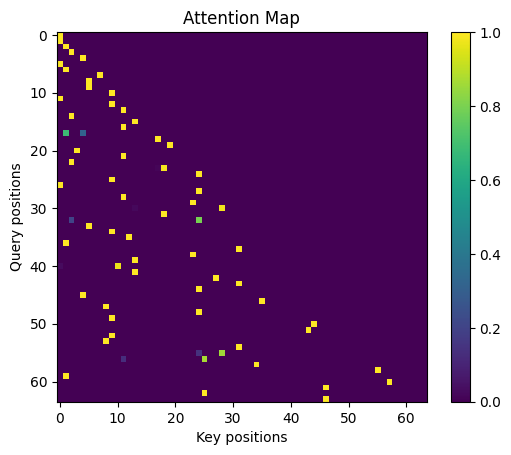

In [23]:
from torch.nn import functional as F
import matplotlib.pyplot as plt

attention = F.softmax(QKt_scaled_masked, dim=-1)

plt.imshow(attention[0].detach().cpu(), cmap='viridis')
plt.colorbar()
plt.title("Attention Map")
plt.xlabel("Key positions")
plt.ylabel("Query positions")
plt.show()

Now that the attention mask is computed we can use it to scale the V tensor. The result of this operation will be the meaning of each pair of words scaled by how much they are relevant to each other in this sentence.

In [24]:
output = attention @ V
output.shape

torch.Size([1, 64, 64])

Let's wrap all that we've done in an attention head class:

In [25]:
class AttentionHead(nn.Module):
    def __init__(
        self, 
        head_size,
        n_positions=CONFIG["n_positions"], 
        n_embd=CONFIG["n_embd"], 
    ):
        nn.Module.__init__(self)
        
        # If head_size is not provided, use the embedding size 
        # (assume single head in transformer block)
        if head_size is None: head_size = n_embd
        self.head_size = head_size

        # Create the weight matrices for the query, key and value
        self.W_q = nn.Linear(n_embd, head_size)
        self.W_k = nn.Linear(n_embd, head_size)
        self.W_v = nn.Linear(n_embd, head_size)

        # Create the causal mask and register as a buffer so it's not a parameter (not trainable)
        self.register_buffer("mask", ~torch.tril(torch.ones(n_positions, n_positions)).bool())
        
    def forward(self, x):
        B, T, C = x.shape
        
        # Project the input into the query, key and value spaces
        # (B, T, C) -> (B, T, head_size)
        Q = self.W_q(x)
        K = self.W_k(x)
        V = self.W_v(x)

        # Matrix multiply the query and key matrices to get the attention scores
        # (how close each query is to each key)
        # (B, T, head_size) @ (B, head_size, T) -> (B, T, T)
        Kt = K.transpose(-2, -1)
        QKt = Q @ Kt

        # Scale the attention scores by the square root of the head size
        # (keep attention scores from exploding otherwise softmax will 
        # saturate and create one hot vectors)
        # (B, T, T) / sqrt(head_size) -> (B, T, T)
        QKt_scaled = QKt / torch.sqrt(torch.tensor(self.head_size))

        # Mask the future tokens so that each token can only attend to previous tokens
        # (B, T, T) -> (B, T, T)
        mask = self.mask[:T, :T].to(x.device)
        QKt_masked = QKt_scaled.masked_fill(mask, float("-inf"))

        # Create the attention weights by applying a softmax to the masked attention scores
        # (B, T, T) -> (B, T, T)
        attention = F.softmax(QKt_masked, dim=-1)

        # Map the attention weights to the value space
        # in order to create an output with the same shape as the input (batch, time, channels)
        # but now with the actual meaning of each word (eg: "the" can now have an embedding of "cat" when input is "the cat jumped")
        # (B, T, T) @ (B, T, head_size) -> (B, T, head_size)
        out = attention @ V

        # Return the output
        return out

# Run a batch through the attention head
with torch.no_grad():
    x, y = sample_batch(1)
    x = token_embedding_table(x)
    out = AttentionHead(CONFIG["n_embd"] // 2)(x)
out.shape, out

(torch.Size([1, 64, 32]),
 tensor([[[-6.2871e-01,  5.5729e-01,  3.9950e-01,  ..., -7.5330e-02,
           -1.0007e+00, -5.5373e-02],
          [-4.0861e-01,  2.7832e-01, -1.6683e-01,  ...,  4.8422e-01,
           -3.7225e-01, -3.0426e-02],
          [-1.5787e-01,  2.0208e-01, -7.7338e-04,  ...,  3.6388e-01,
           -2.8551e-01, -5.5216e-02],
          ...,
          [ 3.0636e-01,  1.6809e-02, -3.5311e-02,  ...,  1.7667e-01,
            3.6815e-01, -8.9766e-02],
          [ 1.7321e-01,  2.6750e-02, -3.1648e-02,  ...,  1.0945e-01,
            2.1848e-01, -1.2628e-01],
          [ 2.6448e-01,  3.6095e-02, -5.0754e-02,  ...,  1.6802e-01,
            3.6531e-01, -1.0819e-01]]]))

Create a class that bundles N attention heads into a single construct that forwards the input through all heads and concatenates the outputs back
into a single tensor of the same shape as the input.

In [26]:
class MultiHeadAttention(nn.Module):
    def __init__(self, 
        n_heads=CONFIG["n_head"], 
        n_embd=CONFIG["n_embd"],
    ):
        nn.Module.__init__(self)
        
        # Create the N attention heads
        head_size = n_embd // n_heads
        self.heads = nn.ModuleList([AttentionHead(head_size) for _ in range(n_heads)])

        # Create the weight matrix that will project the concatenated 
        # outputs back into the same shape to allow the model to learn 
        # to mix the outputs of each head (otherwise each head could only 
        # influence a section of the resulting embedding)
        self.W_o = nn.Linear(n_embd, n_embd)

    def forward(self, x):
        # Run the input through all heads and collect the outputs
        outs = []
        for head in self.heads: # TODO: vectorize this?
            out = head(x)
            outs.append(out)

        # Concatenate the outputs of all heads back into the original shape
        # [(B, T, head_size) for _ in range(n_heads)] -> (B, T, n_heads * head_size)
        mha_out = torch.concat(outs, dim=-1)

        # Project the concatenated outputs back into the same shape as the input
        # (this allows the model to learn to mix the outputs of each head)
        mha_out = self.W_o(mha_out)
        return mha_out

# Run a batch through the multi-head attention
with torch.no_grad():
    x, _ = sample_batch(1)
    x = token_embedding_table(x)
    out = MultiHeadAttention(n_heads=2)(x)
out.shape, out

(torch.Size([1, 64, 64]),
 tensor([[[ 0.0723,  0.1348,  0.0697,  ..., -0.1432,  0.2313,  0.5425],
          [-0.1508,  0.0804, -0.0188,  ..., -0.1089, -0.0893,  0.4143],
          [ 0.0981,  0.0664,  0.0143,  ..., -0.0285,  0.2798, -0.0191],
          ...,
          [-0.0661, -0.0869, -0.0496,  ..., -0.0862, -0.0640,  0.0413],
          [-0.0981, -0.1206,  0.0238,  ..., -0.1214, -0.0926,  0.1038],
          [-0.0555, -0.0435, -0.0266,  ..., -0.1261, -0.1201,  0.0794]]]))

Now let's create a faster attention implementation that does exactly the same thing but with less tensor operations by packing the Q, K, V matrices into a single tensor and then packing all heads into a single tensor as well, this will drastically reduce the number of operations and speed up the computation.

In [27]:
class FastMultiHeadAttention(nn.Module):
    def __init__(
        self, 
        n_heads,
        n_embd=CONFIG["n_embd"],
        block_size=CONFIG["n_positions"]
    ):
        nn.Module.__init__(self)
        head_size = n_embd // n_heads
        self.n_heads = n_heads
        self.head_size = head_size
        
        # Create single tensor with all weights for Q, K, V
        self.W_qkv = nn.Linear(n_embd, n_embd * 3)
        
        # Create the weight matrix that will project the concatenated 
        # outputs back into the same shape to allow the model to learn 
        # to mix the outputs of each head (otherwise each head could only 
        # influence a section of the resulting embedding)
        self.W_o = nn.Linear(n_embd, n_embd)

        # Create the causal mask and register as a buffer so it's not a parameter (not trainable)
        self.register_buffer("mask", ~torch.tril(torch.ones(block_size, block_size)).bool())

    def forward(self, x):
        B, T, C = x.shape

        # Project the input into the query, key and value spaces
        # (B, T, C) -> (B, T, 3 * n_embd)
        QKV = self.W_qkv(x)

        # Split the concatenated Q, K, V into separate tensors
        # (B, T, 3 * n_embd) -> [(B, T, n_embd) for _ in range(3)]
        Q, K, V = torch.chunk(QKV, 3, dim=-1)

        # Reshape the tensors to split the embedding dimension into multiple heads
        # (B, T, n_embd) -> (B, T, n_heads, head_size)
        Q = Q.view(B, T, self.n_heads, self.head_size)
        K = K.view(B, T, self.n_heads, self.head_size)
        V = V.view(B, T, self.n_heads, self.head_size)

        # Transpose the tensors so that the head dimension is first 
        # (B, T, n_heads, head_size) -> (B, n_heads, T, head_size)
        Q = Q.transpose(1, 2)
        K = K.transpose(1, 2)
        V = V.transpose(1, 2)

        # Matrix multiply the query and key matrices to get the attention scores
        # (B, n_heads, T, head_size) @ (B, n_heads, head_size, T) -> (B, n_heads, T, T)
        Kt = K.transpose(-2, -1)
        QKt = Q @ Kt

        # Scale the attention scores by the square root of the head size
        # (keep attention scores from exploding otherwise softmax will 
        # saturate and create one hot vectors)
        QKt_scaled = QKt / torch.sqrt(torch.tensor(self.head_size)).to(x.device)

        # Mask the future tokens so that each token can only attend to previous tokens
        mask = self.mask[:T, :T].unsqueeze(0).unsqueeze(0).to(x.device) # TODO: send to device earlier?
        QKt_masked = QKt_scaled.masked_fill(mask, float("-inf"))

        # Apply the softmax to the masked attention scores
        # (B, n_heads, T, T) -> (B, n_heads, T, T)
        attention = F.softmax(QKt_masked, dim=-1)

        # Matrix multiply the attention scores with the value matrix to get the output
        # (B, n_heads, T, T) @ (B, n_heads, T, head_size) -> (B, n_heads, T, head_size)
        V_scaled = attention @ V

        # Transpose the output so that the head dimension is last
        # (B, n_heads, T, head_size) -> (B, T, n_heads, head_size)
        V_scaled_t = V_scaled.transpose(1, 2)

        # Reshape the output to concatenate the heads back into the original shape
        # (B, T, n_heads, head_size) -> (B, T, n_embd)
        V_scaled_t_realigned = V_scaled_t.contiguous().view(B, T, C)

        # Project the concatenated outputs back into the same shape as the input
        # (this allows the model to learn to mix the outputs of each head)
        output = self.W_o(V_scaled_t_realigned) 

        # Return the multi-head attention output
        return output

# Run a batch through the fast multi-head attention
with torch.no_grad():
    x, _ = sample_batch(1)
    x = token_embedding_table(x)
    out = FastMultiHeadAttention(2)(x)
    out.shape, out

Now let's create the feedforward network that follows the attention layer in the transformer block. The FFN layer should scale the input up by 4x, apply a non-linearity and then scale it back down to the original dimensions.

In [28]:
ffn1 = nn.Linear(n_embd, n_embd * 4)
gelu = nn.GELU()
ffn2 = nn.Linear(n_embd * 4, n_embd)
n_heads = CONFIG["n_head"]
head_size = n_embd // n_heads
lm_head = nn.Linear(n_embd, head_size)
output_head = lm_head(ffn2(gelu(ffn1(output))))
output_head.shape, output_head

(torch.Size([1, 64, 32]),
 tensor([[[-1.0111, -0.5878, -1.8574,  ..., -3.1551,  0.4941,  0.6194],
          [-1.0111, -0.5878, -1.8574,  ..., -3.1551,  0.4941,  0.6194],
          [-3.4090,  0.2232,  1.7349,  ..., -2.4817,  0.7541,  3.5620],
          ...,
          [ 0.8247,  0.1438,  1.8798,  ..., -2.8508, -0.5189, -0.9771],
          [-0.5656, -1.9689, -0.0737,  ..., -2.9956, -0.6133,  0.3627],
          [ 0.8247,  0.1438,  1.8798,  ..., -2.8508, -0.5189, -0.9771]]],
        grad_fn=<ViewBackward0>))

Wrap the FFN in a class:

In [29]:
class FeedForward(nn.Module):
    def __init__(self, n_embd=CONFIG["n_embd"]):
        nn.Module.__init__(self)
        
        self.ffn1 = nn.Linear(n_embd, n_embd * 4)
        self.gelu = nn.GELU(approximate='tanh')  # TODO: hugging face does this... why?
        self.ffn2 = nn.Linear(n_embd * 4, n_embd)

    def forward(self, x):
        x = self.ffn1(x)
        x = self.gelu(x)
        x = self.ffn2(x)
        return x

# Run a batch through the feedforward network
with torch.no_grad():
    x,y = sample_batch(1)
    x = token_embedding_table(x)
    mha_out = MultiHeadAttention()(x)
    out = FeedForward()(mha_out)
    out.shape, out

Now that we have all the components of a transformer block, let's wrap them in a class:

In [30]:
class TransformerBlock(nn.Module):
    def __init__(
        self, 
        n_embd=CONFIG["n_embd"], 
        n_heads=CONFIG["n_head"], 
        layer_norm_enabled=CONFIG["layer_norm_enabled"]
    ):
        nn.Module.__init__(self)
        self.head = FastMultiHeadAttention(n_heads)
        self.ffn = FeedForward(n_embd)
        self.ln1 = nn.LayerNorm(n_embd) if layer_norm_enabled else nn.Identity()
        self.ln2 = nn.LayerNorm(n_embd) if layer_norm_enabled else nn.Identity()

    def forward(self, x):
        # Normalize the input features, run them through the 
        # attention layer and then add the input (residual connection)
        x = x + self.head(self.ln1(x))

        # Normalize the input features, run them through the 
        # feedforward network and then add the input (residual connection)
        x = x + self.ffn(self.ln2(x))

        # Return the transformed features
        return x

# Run a batch through the transformer block
with torch.no_grad():
    x, y = sample_batch(1)
    x = token_embedding_table(x)
    out = TransformerBlock()(x)
out.shape, out

(torch.Size([1, 64, 64]),
 tensor([[[-0.8046, -0.4020, -1.0111,  ...,  1.5243, -2.1069, -0.9921],
          [-0.1361,  0.9659, -1.3201,  ..., -0.6141, -0.3109, -0.4299],
          [ 1.0033,  0.4208,  1.3864,  ...,  1.9778, -0.0384,  0.1800],
          ...,
          [ 0.4173, -0.0136,  0.6401,  ..., -0.8636,  0.1322, -0.1485],
          [ 1.3681, -0.7899,  2.1748,  ...,  0.8491,  2.1643,  0.6674],
          [ 0.9768, -0.4143, -2.2089,  ..., -0.8957,  1.1405,  1.5038]]]))

Now that we have the transformer block, let's create the entire transformer model (decoder only):

In [31]:
class Transformer(nn.Module):
    def __init__(
        self,
        vocab_size=TOKENIZER.get_vocab_size(),
        n_embd=CONFIG["n_embd"], 
        n_layer=CONFIG["n_layer"], 
        n_positions=CONFIG["n_positions"]
    ):
        nn.Module.__init__(self)

        # Create the token embedding table (maps tokens to learnable embeddings)
        # (B, T) -> (B, T, C)
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)

        # Create the position embedding table (maps positions to learnable embeddings)
        # (T,) -> (T, C)
        self.position_embedding_table = nn.Embedding(n_positions, n_embd)

        # Create the transformer blocks
        self.blocks = nn.ModuleList([TransformerBlock() for _ in range(n_layer)])

        # Create the language model head (maps the final layer to the vocabulary size) 
        # (B, T, C) -> (B, T, vocab_size)
        self.lm_head = nn.Linear(n_embd, vocab_size)
        
        # TODO: hugging face does this... why?
        self.lm_head.weight = self.token_embedding_table.weight  # Share weights!

        # Create the final layer normalization (normalizes the output of the last transformer block)
        # (B, T, C) -> (B, T, C)
        self.ln_final = nn.LayerNorm(n_embd) if CONFIG["layer_norm_enabled"] else nn.Identity()

    def forward(self, x):
        B, T = x.shape

        # Create token embeddings
        # (B, T) -> (B, T, C)
        tok_emb = self.token_embedding_table(x)

        # Create position embeddings and unsqueeze 
        # them to align with the token embeddings
        # (T,) -> (T, C) -> (1, T, C)
        pos = torch.arange(T, device=x.device)
        pos_emb = self.position_embedding_table(pos)
        pos_emb = pos_emb.unsqueeze(0)

        # Add the token embeddings and 
        # position embeddings to create the input
        x = tok_emb + pos_emb

        # Run the input through all transformer blocks
        for block in self.blocks: x = block(x)

        # Project the output to the vocabulary size
        # Normalize the output of the last transformer block and feed it through the language model head
        # to project to the vocabulary size
        # (B, T, C) -> (B, T, vocab_size)
        x = self.lm_head(self.ln_final(x))

        # Return the projected output
        return x

    @torch.no_grad()
    def generate(self, text, max_len=20):
        device = next(self.parameters()).device
        n_positions = CONFIG["n_positions"]
        tokens = encode(text)
        #tokens = pad(tokens)
        tokens_t = torch.tensor(tokens).to(device)
        tokens_t = tokens_t.unsqueeze(0)#view(1, -1)
        output_tokens = []
        while len(output_tokens) < max_len:
            logits = self(tokens_t)
            logits = logits[:, -1, :]
            probs = F.softmax(logits, dim=-1)
            idx = torch.multinomial(probs, num_samples=1)
            idx = idx.squeeze().item()
            tokens.append(idx)
            tokens = tokens[-n_positions:]
            tokens_t = torch.tensor(tokens).to(device).unsqueeze(0)
            #tokens_t = tokens_t.view(1, n_positions)
            output_tokens.append(idx)
        text = decode(output_tokens)
        return text

# Run a batch through the transformer
with torch.no_grad():
    x, y = sample_batch(1)
    out = Transformer()(x)
out.shape, out[0][0]

(torch.Size([1, 64, 82]),
 tensor([-4.5647e+00, -1.0647e+01,  8.2764e+00,  1.0276e+00,  5.1039e+00,
         -2.3700e+01,  1.1162e+01,  5.0331e+00,  3.8635e+00,  1.5138e+00,
          1.0782e+01, -5.3042e+00, -7.5082e+00,  1.0509e+01, -9.3441e+00,
          3.4694e-02, -3.5540e+00, -4.8633e+00, -4.6614e+00, -4.7250e+00,
          9.4984e+00,  1.4673e-01, -1.4379e+01, -4.6688e+00, -2.0555e+00,
          9.3292e-01, -8.4266e+00,  2.9240e+00, -8.9399e+00,  2.7576e+00,
          8.9368e+00, -1.3070e+01, -1.5805e+00, -3.4050e+00, -3.9690e+00,
          1.2159e+00, -3.5961e+00,  2.7832e+00, -1.1602e+00, -7.9268e+00,
          6.1101e+00,  3.3271e+00, -7.4554e+00,  6.1858e+00,  2.1873e+00,
          5.3507e+00, -1.2838e+01, -2.6298e+00,  1.1374e+01, -1.2259e+00,
          2.1082e+01, -4.5270e+00,  3.5744e+00, -5.0846e+00,  2.7776e+00,
          8.7249e+00,  3.9700e+01, -4.6659e+00, -2.9604e+00, -2.1160e+00,
         -6.3838e+00, -4.7299e+00, -2.0361e+01,  7.6328e+00, -8.0375e+00,
          1.

Create the training dataset, which returns a different sequence of length `block_size` for each index in the dataset:

In [32]:
from torch.utils.data import Dataset

class TrainDataset(Dataset):
    def __init__(
        self, 
        tokens, 
        n_positions=CONFIG["n_positions"]
    ):
        self.tokens = tokens
        self.n_positions = n_positions

    def __getitem__(self, idx):
        x = self.tokens[idx:idx+self.n_positions]
        y = self.tokens[idx+1:idx+self.n_positions+1]
        return torch.tensor(x), torch.tensor(y)

    def __len__(self):
        return len(self.tokens) - self.n_positions


# Test retrieving first item from the dataset
train_dataset = TrainDataset(DATASET_TOKENS)
x, y = next(iter(train_dataset))
print("x:" + decode(x.tolist())[:10])
print("y:" + decode(y.tolist())[:10])

x:FcfX"IZ"N\
y:cfX"IZ"N\Y


Create train data loader that iterates the dataset in random batches instead of sequential items:

In [33]:
from torch.utils.data import DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=True,
    # TODO: move to top
    num_workers=0,  # MPS doesn't benefit from >0 workers
    pin_memory=False,  # Not needed for MPS
    drop_last=True  # Ensures consistent batch sizes
)

# Test retrieving first batch from the data loader
for x, y in train_loader:
    for i in range(10):
        print("x:" + decode(x[i].tolist())[:10])
        print("y:" + decode(y[i].tolist())[:10])
        print("---")
    break

x:cVV]hg"[]j
y:VV]hg"[]jY
---
x:Mccb"UZhYf
y:ccb"UZhYf"
---
x:"XYZh"]b"h
y:XYZh"]b"h\
---
x:Y"`YUfbYX"
y:"`YUfbYX"a
---
x:"\Y][\h)"k
y:\Y][\h)"kU
---
x:XYX"gd]XYf
y:YX"gd]XYf)
---
x:Y"hckUfXg"
y:"hckUfXg"@
---
x:UbX"h\Y"\c
y:bX"h\Y"\cV
---
x:i`Y"hc"Ugg
y:`Y"hc"UggU
---
x:ci"k]``#$!
y:i"k]``#$!$
---


Create the transformer model:

In [34]:
model = Transformer()
#model = torch.compile(model, mode="reduce-overhead") # TODO: no gain on mps?
model.to(DEVICE)
model.train()

Transformer(
  (token_embedding_table): Embedding(82, 64)
  (position_embedding_table): Embedding(64, 64)
  (blocks): ModuleList(
    (0-1): 2 x TransformerBlock(
      (head): FastMultiHeadAttention(
        (W_qkv): Linear(in_features=64, out_features=192, bias=True)
        (W_o): Linear(in_features=64, out_features=64, bias=True)
      )
      (ffn): FeedForward(
        (ffn1): Linear(in_features=64, out_features=256, bias=True)
        (gelu): GELU(approximate='tanh')
        (ffn2): Linear(in_features=256, out_features=64, bias=True)
      )
      (ln1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (ln2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    )
  )
  (lm_head): Linear(in_features=64, out_features=82, bias=True)
  (ln_final): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
)

If `tune_batch_size` is true, find the optimal batch size and gradient accumulation steps for the model:

In [35]:
if CONFIG["tune_batch_size"]:
    from aiml_notebooks import find_optimal_batch_config
    vocab_size = TOKENIZER.get_vocab_size()
    result = find_optimal_batch_config(
        model=model,
        vocab_size=vocab_size,
        n_positions=CONFIG["n_positions"],
    )
    recommended = result['recommended']
    if CONFIG["batch_size"] == "auto": CONFIG["batch_size"] = recommended['batch_size']
    if CONFIG["gradient_accumulation_steps"] == "auto": CONFIG["gradient_accumulation_steps"] = recommended['gradient_accumulation_steps']

Create utility to measure the models' gradient norm (used to monitor training stability):

In [36]:
# Add this to your training loop to monitor gradients
def get_grad_norm(model):
    total_norm = 0
    for p in model.parameters():
        if p.grad is not None:
            param_norm = p.grad.data.norm(2)
            total_norm += param_norm.item() ** 2
    total_norm = total_norm ** (1. / 2)
    return total_norm

# In your training loop, after loss.backward():
grad_norm = get_grad_norm(model)
grad_norm

0.0

Create the training loop and train for `n_epochs`:

In [ ]:
from tqdm import tqdm

def train(
    model, 
    n_epochs=CONFIG['n_epochs'], 
    lr=CONFIG["learning_rate"], 
    gradient_accumulation_steps=CONFIG["gradient_accumulation_steps"]
):
    # Create the optimizer
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

    # Initialize lists to store losses and gradient norms
    losses = []
    grad_norms = []

    # Train for `n_epochs`
    for epoch in range(n_epochs):
        # Set the model to training mode (sanity: we may have set it to evaluation mode at some point last epoch)
        model.train()

        # Zero the gradients
        optimizer.zero_grad()

        # Iterate over the training data loader
        batch_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{n_epochs}")
        for batch_idx, (x, y) in enumerate(batch_bar):
            # Move the batch to the device
            x, y = x.to(DEVICE), y.to(DEVICE)

            # Forward pass
            logits = model(x)

            # Permute the logits to match the shape of the targets
            # (B, T, C) -> (B, C, T)
            logits = logits.permute(0, 2, 1) # TODO: review this

            # Compute the loss
            loss = F.cross_entropy(logits, y)

            # Accumulate the loss
            losses.append(loss.item())

            # Backward pass
            # (each batch is scaled by gradient_accumulation_steps to avoid gradient explosion)
            # TODO: review this
            (loss / gradient_accumulation_steps).backward()

            # In case this is an optimization step, then adjust the model 
            # parameters based on the gradients accumulated so far
            is_optimization_step = ((batch_idx + 1) % gradient_accumulation_steps == 0) or (batch_idx + 1 == len(train_loader))
            if is_optimization_step:
                # Calculate the gradient norm 
                # (used to monitor training stability)
                grad_norm = get_grad_norm(model)
                grad_norms.append(grad_norm)
                
                # Log the loss and gradient norm
                batch_bar.set_postfix(
                    loss=f"{loss.item():.4f}",
                    grad_norm=f"{grad_norm:.4f}"
                )

                # Update the model parameters
                optimizer.step()

                # Zero the gradients so we can start accumulating gradients again
                optimizer.zero_grad()
            # In case this is not an optimization step, then just log the loss
            else:
                batch_bar.set_postfix(loss=f"{loss.item():.4f}")

    # Return the training results
    return dict(
        losses=losses,
        grad_norms=grad_norms   
    )

# Train the model for `n_epochs`
losses, grad_norms = train(model, n_epochs=CONFIG['n_epochs'])

Epoch 1/100:  11%|█         | 1706/15579 [00:34<04:29, 51.50it/s, loss=2.5276]                  

Plot training losses and gradient norms:

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4)) 
axes[0].plot(losses)
axes[0].set_title("Losses")
axes[1].plot(grad_norms)
axes[1].set_title("Grad Norms")
plt.tight_layout()
plt.show()

Test generation with the trained model:

In [ ]:
model.eval()
print(model.generate("Frodo picked up the sword", max_len=1024))

Check activations of each layer:

In [ ]:
# Track activations - respect the layer_norm_enabled flag
def track_block_activations(model, x):
    """Track activations at the output of each block."""
    stats = []
    
    model.eval()
    with torch.no_grad():
        # Get embeddings
        x = model.token_embedding_table(x)
        pos = torch.arange(x.size(1), device=x.device)
        pos_emb = model.position_embedding_table(pos).unsqueeze(0)
        x = x + pos_emb
        
        # Track initial state
        stats.append({
            'layer': 'input',
            'mean': x.mean().item(),
            'std': x.std().item(),
            'max_abs': x.abs().max().item()
        })
        
        # Track through each block
        for i, block in enumerate(model.blocks):
            x = block(x)
            stats.append({
                'layer': f'block_{i}',
                'mean': x.mean().item(),
                'std': x.std().item(),
                'max_abs': x.abs().max().item()
            })
        
        # Only apply final layer norm if enabled (same as model's forward pass)
        if CONFIG["layer_norm_enabled"]:
            x = model.ln_final(x)
            stats.append({
                'layer': 'final_ln',
                'mean': x.mean().item(),
                'std': x.std().item(),
                'max_abs': x.abs().max().item()
            })
        else:
            # Track the raw output from last block (no normalization)
            stats.append({
                'layer': 'final',
                'mean': x.mean().item(),
                'std': x.std().item(),
                'max_abs': x.abs().max().item()
            })
    
    return stats

# Get a sample batch
x, y = sample_batch(1)
x = x.to(DEVICE)

# Track activations
stats = track_block_activations(model, x)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

layers = [s['layer'] for s in stats]
max_abs = [s['max_abs'] for s in stats]
stds = [s['std'] for s in stats]

# Plot 1: Maximum absolute values (log scale)
axes[0].semilogy(max_abs, marker='o', linewidth=2, markersize=8, color='red')
axes[0].set_title('Maximum Absolute Activation Values', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Layer', fontsize=12)
axes[0].set_ylabel('Max Abs Value (log scale)', fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(range(len(layers)))
axes[0].set_xticklabels(layers, rotation=45, ha='right')

# Plot 2: Standard deviation
axes[1].plot(stds, marker='s', linewidth=2, markersize=8, color='blue')
axes[1].set_title('Standard Deviation of Activations', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Layer', fontsize=12)
axes[1].set_ylabel('Standard Deviation', fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(range(len(layers)))
axes[1].set_xticklabels(layers, rotation=45, ha='right')

plt.tight_layout()
plt.show()

# Print summary
print("\n" + "="*70)
print("ACTIVATION STATISTICS")
print("="*70)
print(f"{'Layer':<15} {'Mean':>12} {'Std':>12} {'Max Abs':>12}")
print("-"*70)
for s in stats:
    print(f"{s['layer']:<15} {s['mean']:>12.4f} {s['std']:>12.4f} {s['max_abs']:>12.4f}")
print("="*70)

# Calculate growth rate
if len(max_abs) > 1:
    growth_rate = max_abs[-1] / max_abs[0] if max_abs[0] != 0 else float('inf')
    print(f"\nActivation Growth Rate (Final/Initial): {growth_rate:.2f}x")
    print(f"Initial max abs: {max_abs[0]:.4f}")
    print(f"Final max abs: {max_abs[-1]:.4f}")

Load pretrained weights from HuggingFace into our custom GPT-2 model:

In [ ]:
def load_pretrained_weights(model, model_name='openai-community/gpt2'):
    """
    Load pretrained weights from HuggingFace into our custom GPT-2 model.
    
    Args:
        model: Our custom Transformer model instance
        model_name: HuggingFace model identifier (default: 'openai-community/gpt2')
    
    Returns:
        model: The model with loaded weights
    """
    from transformers import GPT2LMHeadModel
    
    print(f"Loading pretrained weights from {model_name}...")
    hf_model = GPT2LMHeadModel.from_pretrained(model_name)
    hf_state_dict = hf_model.state_dict()
    
    # Create mapping from HuggingFace names to our names
    our_state_dict = model.state_dict()
    
    # 1. Token and position embeddings
    our_state_dict['token_embedding_table.weight'].copy_(hf_state_dict['transformer.wte.weight'])
    our_state_dict['position_embedding_table.weight'].copy_(hf_state_dict['transformer.wpe.weight'])
    
    # 2. Final layer norm
    our_state_dict['ln_final.weight'].copy_(hf_state_dict['transformer.ln_f.weight'])
    our_state_dict['ln_final.bias'].copy_(hf_state_dict['transformer.ln_f.bias'])
    
    # 3. Load weights for each transformer block
    n_layers = CONFIG["n_layer"]
    for i in range(n_layers):
        # Layer norm 1 (pre-attention)
        our_state_dict[f'blocks.{i}.ln1.weight'].copy_(hf_state_dict[f'transformer.h.{i}.ln_1.weight'])
        our_state_dict[f'blocks.{i}.ln1.bias'].copy_(hf_state_dict[f'transformer.h.{i}.ln_1.bias'])
        
        # Attention QKV projection (combined)
        # HuggingFace stores as (768, 2304) but PyTorch Linear expects (2304, 768) for weight
        # So we need to transpose
        hf_qkv_weight = hf_state_dict[f'transformer.h.{i}.attn.c_attn.weight']
        hf_qkv_bias = hf_state_dict[f'transformer.h.{i}.attn.c_attn.bias']
        our_state_dict[f'blocks.{i}.head.W_qkv.weight'].copy_(hf_qkv_weight.T)  # Transpose!
        our_state_dict[f'blocks.{i}.head.W_qkv.bias'].copy_(hf_qkv_bias)
        
        # Attention output projection
        hf_o_weight = hf_state_dict[f'transformer.h.{i}.attn.c_proj.weight']
        hf_o_bias = hf_state_dict[f'transformer.h.{i}.attn.c_proj.bias']
        our_state_dict[f'blocks.{i}.head.W_o.weight'].copy_(hf_o_weight.T)  # Transpose!
        our_state_dict[f'blocks.{i}.head.W_o.bias'].copy_(hf_o_bias)
        
        # Layer norm 2 (pre-FFN)
        our_state_dict[f'blocks.{i}.ln2.weight'].copy_(hf_state_dict[f'transformer.h.{i}.ln_2.weight'])
        our_state_dict[f'blocks.{i}.ln2.bias'].copy_(hf_state_dict[f'transformer.h.{i}.ln_2.bias'])
        
        # FFN first layer (expansion)
        hf_fc_weight = hf_state_dict[f'transformer.h.{i}.mlp.c_fc.weight']
        hf_fc_bias = hf_state_dict[f'transformer.h.{i}.mlp.c_fc.bias']
        our_state_dict[f'blocks.{i}.ffn.ffn1.weight'].copy_(hf_fc_weight.T)  # Transpose!
        our_state_dict[f'blocks.{i}.ffn.ffn1.bias'].copy_(hf_fc_bias)
        
        # FFN second layer (projection)
        hf_proj_weight = hf_state_dict[f'transformer.h.{i}.mlp.c_proj.weight']
        hf_proj_bias = hf_state_dict[f'transformer.h.{i}.mlp.c_proj.bias']
        our_state_dict[f'blocks.{i}.ffn.ffn2.weight'].copy_(hf_proj_weight.T)  # Transpose!
        our_state_dict[f'blocks.{i}.ffn.ffn2.bias'].copy_(hf_proj_bias)
    
    # Note: lm_head weights are tied to token_embedding_table.weight, so no separate loading needed
    
    print(f"✓ Successfully loaded {n_layers} transformer blocks")
    print("✓ Weight tying preserved (lm_head shares weights with token embeddings)")
    
    return model

# Load pretrained GPT-2 weights from HuggingFace
model_pretrained = Transformer().to(DEVICE)
model_pretrained = load_pretrained_weights(model_pretrained)

# Test generation with pretrained model
model_pretrained.eval()
print(model_pretrained.generate("Frodo picked up the sword", max_len=1024))